# AdaBoost Scaling Experiment

**Experiment 2**: Vary n_estimators from 1 to 200 and observe performance

**Datasets**: Breast Cancer, Adult Income, Covertype, MNIST (Full - 10 classes)

In [1]:
import time

t1 = time.perf_counter()

In [2]:
# ============================================
# ADA BOOST SCALING EXPERIMENT - STAGED APPROACH
# Experiment 2: Vary n_estimators from 1 to 200
# Using staged_predict to record accuracy at each step
# ============================================

import sys
import os
import time
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.append("..")

from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)

# ============================================
# IMPORT EXPERIMENT FUNCTIONS
# ============================================
# These functions are now in src/utils/adaboost_scale_experiment_utils.py
from src.utils.adaboost_scale_experiment_utils import (
    get_memory_usage,
    run_all_staged,
    plot_adaboost_scaling,
    compare_with_sklearn,
)


# Set style
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("=" * 60)
print("ADA BOOST SCALING EXPERIMENT - STAGED APPROACH")
print("=" * 60)

ADA BOOST SCALING EXPERIMENT - STAGED APPROACH


# Configuration

In [ ]:
# ============================================
# EXPERIMENT CONFIGURATION
# ============================================
CONFIG = {
    "max_estimators": 10,  # Maximum number of estimators
    "step": 1,  # Record at 1, 5, 10, 15, ..., 200
    "test_size": 0.2,  # Train/test split ratio
    "random_state": 42,  # Fixed seed for reproducibility
    "sklearn_n_estimators": 10,  # For sklearn comparison
    "covertype_sample_size": 5000,  # Covertype sample size (min 5000 per spec)
    "mnist_sample_size": 500,  # MNIST sample size
}

# Extract values for easy access
MAX_ESTIMATORS = CONFIG["max_estimators"]
STEP = CONFIG["step"]
TEST_SIZE = CONFIG["test_size"]
RANDOM_STATE = CONFIG["random_state"]
SKLEARN_N_ESTIMATORS = CONFIG["sklearn_n_estimators"]
COVERTYPE_SAMPLE_SIZE = CONFIG.get("covertype_sample_size")
MNIST_SAMPLE_SIZE = CONFIG.get("mnist_sample_size")

# Create rounds list: [1, 5, 10, 15, ..., 200]
N_ESTIMATORS_LIST = list(range(STEP, MAX_ESTIMATORS + 1, STEP))

print("\n" + "=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(
    f"\n  Recording at n_estimators: {N_ESTIMATORS_LIST[:10]}...{N_ESTIMATORS_LIST[-5:]}"
)
print("=" * 60)


EXPERIMENT CONFIGURATION
  max_estimators: 10
  step: 1
  test_size: 0.2
  random_state: 42
  sklearn_n_estimators: 10
  covertype_sample_size: 5000
  mnist_sample_size: 500

  Recording at n_estimators: [1, 1, 2, 3, 4, 5, 6, 7, 8, 9]...[6, 7, 8, 9, 10]


# Load datasets

In [4]:
# Helper function to get memory usage
memory_stats = []

# Load Breast Cancer
X_bc, y_bc, _ = load_breast_cancer_data(optimize_memory=True, verbose=False)
memory_stats.append(
    {
        "Dataset": "Breast_Cancer",
        "X_memory_mb": get_memory_usage(X_bc),
        "y_memory_mb": get_memory_usage(y_bc),
        "X_type": type(X_bc).__name__,
        "X_dtype": X_bc.dtypes if hasattr(X_bc, "dtypes") else X_bc.dtype,
    }
)

# Load Adult Income
X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
y_adult_binary = (y_adult.str.replace(".", "", regex=False) == ">50K").astype(int)
memory_stats.append(
    {
        "Dataset": "Adult_Income",
        "X_memory_mb": get_memory_usage(X_adult),
        "y_memory_mb": get_memory_usage(y_adult_binary),
        "X_type": type(X_adult).__name__,
        "X_dtype": X_adult.dtypes if hasattr(X_adult, "dtypes") else X_adult.dtype,
    }
)

# Load Covertype with subsampling
X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
if COVERTYPE_SAMPLE_SIZE is not None and COVERTYPE_SAMPLE_SIZE < len(X_cover):
    print(f"  Subsampling Covertype: {len(X_cover)} → {COVERTYPE_SAMPLE_SIZE} samples")
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_cover), COVERTYPE_SAMPLE_SIZE, replace=False
    )
    X_cover = X_cover.iloc[sample_indices]
    y_cover = y_cover.iloc[sample_indices]
else:
    print(f"  Using full Covertype dataset: {len(X_cover)} samples")
memory_stats.append(
    {
        "Dataset": "Covertype",
        "X_memory_mb": get_memory_usage(X_cover),
        "y_memory_mb": get_memory_usage(y_cover),
        "X_type": type(X_cover).__name__,
        "X_dtype": X_cover.dtypes if hasattr(X_cover, "dtypes") else X_cover.dtype,
    }
)

# Load MNIST with subsampling
X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=True, verbose=False, return_numpy=False
)
if MNIST_SAMPLE_SIZE is not None and MNIST_SAMPLE_SIZE < len(X_mnist):
    print(f"  Subsampling MNIST: {len(X_mnist)} → {MNIST_SAMPLE_SIZE} samples")
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_mnist), MNIST_SAMPLE_SIZE, replace=False
    )
    X_mnist = X_mnist.iloc[sample_indices]
    y_mnist = y_mnist.iloc[sample_indices]
else:
    print(f"  Using full MNIST dataset: {len(X_mnist)} samples")
memory_stats.append(
    {
        "Dataset": "MNIST",
        "X_memory_mb": get_memory_usage(X_mnist),
        "y_memory_mb": get_memory_usage(y_mnist),
        "X_type": type(X_mnist).__name__,
        "X_dtype": X_mnist.dtypes if hasattr(X_mnist, "dtypes") else X_mnist.dtype,
    }
)

# Process Covertype
y_cover_flat = y_cover.values.ravel()

# Create datasets dictionary
datasets = {
    "Breast_Cancer": (X_bc.values, y_bc.values),
    "Adult_Income": (X_adult.values, y_adult_binary.values),
    "Covertype": (X_cover.values, y_cover_flat),
    "MNIST": (X_mnist, y_mnist),
}

print("\n" + "=" * 60)
print("DATASETS LOADED")
print("=" * 60)

total_memory = 0
for name, (X, y) in datasets.items():
    if hasattr(X, "memory_usage"):
        mem = X.memory_usage(deep=True)
        x_mem = mem.sum() / 1024**2 if hasattr(mem, "sum") else mem / 1024**2
    else:
        x_mem = X.nbytes / 1024**2

    if hasattr(y, "memory_usage"):
        mem = y.memory_usage(deep=True)
        y_mem = mem.sum() / 1024**2 if hasattr(mem, "sum") else mem / 1024**2
    else:
        y_mem = y.nbytes / 1024**2

    total_memory += x_mem + y_mem

    print(f"\n{name}:")
    print(f"  Shape: {X.shape}")
    print(f"  Classes: {np.unique(y)}")
    print(f"  X type: {type(X).__name__}")
    print(f"  X memory: {x_mem:.1f} MB")
    print(f"  y memory: {y_mem:.1f} MB")
    print(f"  Total memory: {x_mem + y_mem:.1f} MB")

print(f"\n{'=' * 60}")
print(f"TOTAL MEMORY FOR ALL DATASETS: {total_memory:.1f} MB")
print("=" * 60)

  Subsampling Covertype: 581012 → 5000 samples
  Subsampling MNIST: 70000 → 500 samples

DATASETS LOADED

Breast_Cancer:
  Shape: (569, 30)
  Classes: [0 1]
  X type: ndarray
  X memory: 0.1 MB
  y memory: 0.0 MB
  Total memory: 0.1 MB

Adult_Income:
  Shape: (48842, 6)
  Classes: [0 1]
  X type: ndarray
  X memory: 2.2 MB
  y memory: 0.4 MB
  Total memory: 2.6 MB

Covertype:
  Shape: (5000, 10)
  Classes: [1 2 3 4 5 6 7]
  X type: ndarray
  X memory: 0.4 MB
  y memory: 0.0 MB
  Total memory: 0.4 MB

MNIST:
  Shape: (500, 784)
  Classes: [0 1 2 3 4 5 6 7 8 9]
  X type: DataFrame
  X memory: 3.0 MB
  y memory: 0.0 MB
  Total memory: 3.0 MB

TOTAL MEMORY FOR ALL DATASETS: 6.2 MB


# Run experiments

In [5]:
# ============================================
# RUN EXPERIMENT (Using notebook's config)
# ============================================
print("Running AdaBoost scaling experiment (staged approach)...")
results, trained_models, TOTAL_TIME = run_all_staged(
    datasets,
    max_estimators=MAX_ESTIMATORS,  # From your notebook's CONFIG
    step=STEP,  # From your notebook's CONFIG
)

Running AdaBoost scaling experiment (staged approach)...

Running AdaBoost scaling with n_estimators: [1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Total recording points: 11

Processing Breast_Cancer...
  Samples: 569, Features: 30
  Training AdaBoost with max estimators...
  Training complete: 0.06s
  Extracting staged predictions...
  ✅ Results saved to adaboost_scaling_Breast_Cancer_details.csv
  ✅ Metadata saved to adaboost_scaling_Breast_Cancer_metadata.csv

Processing Adult_Income...
  Samples: 48842, Features: 6
  Training AdaBoost with max estimators...
  Training complete: 0.37s
  Extracting staged predictions...
  ✅ Results saved to adaboost_scaling_Adult_Income_details.csv
  ✅ Metadata saved to adaboost_scaling_Adult_Income_metadata.csv

Processing Covertype...
  Samples: 5000, Features: 10
  Training AdaBoost with max estimators...
  Training complete: 0.06s
  Extracting staged predictions...
  ✅ Results saved to adaboost_scaling_Covertype_details.csv
  ✅ Metadata saved to adaboost_s

# Plot results


GENERATING PLOTS

Plotting Breast_Cancer...
  Plot saved to ../figures/adaboost_scaling_Breast_Cancer.png


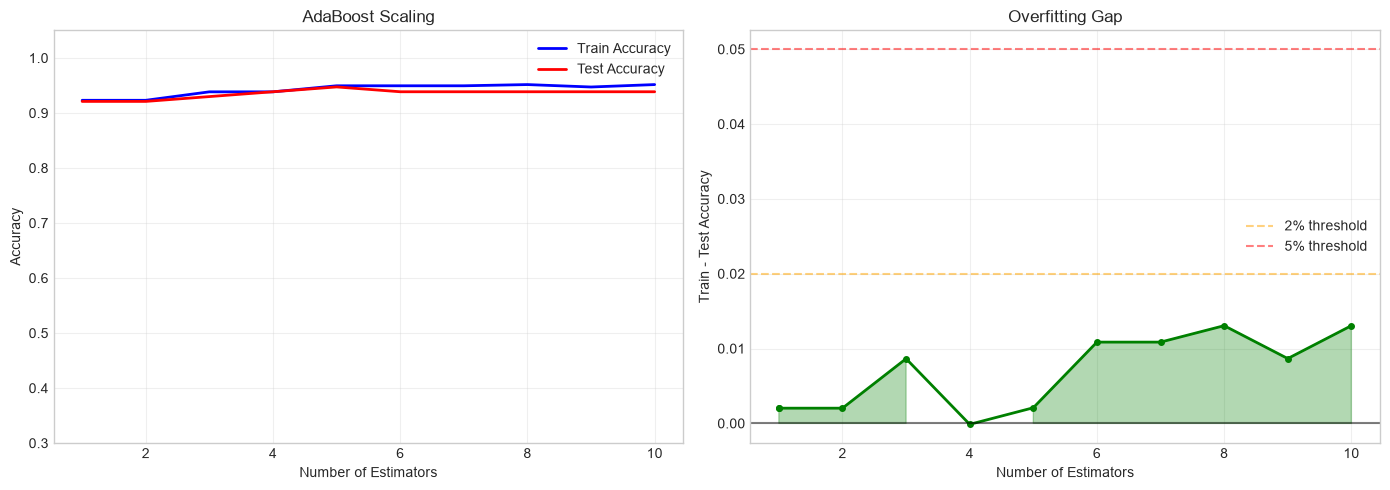


Plotting Adult_Income...
  Plot saved to ../figures/adaboost_scaling_Adult_Income.png


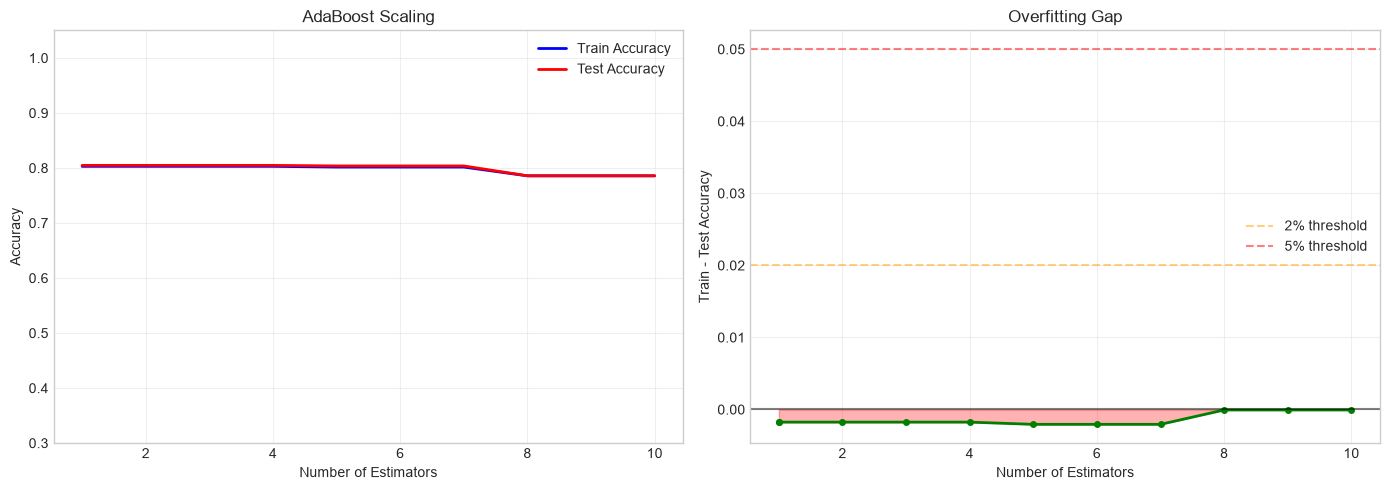


Plotting Covertype...
  Plot saved to ../figures/adaboost_scaling_Covertype.png


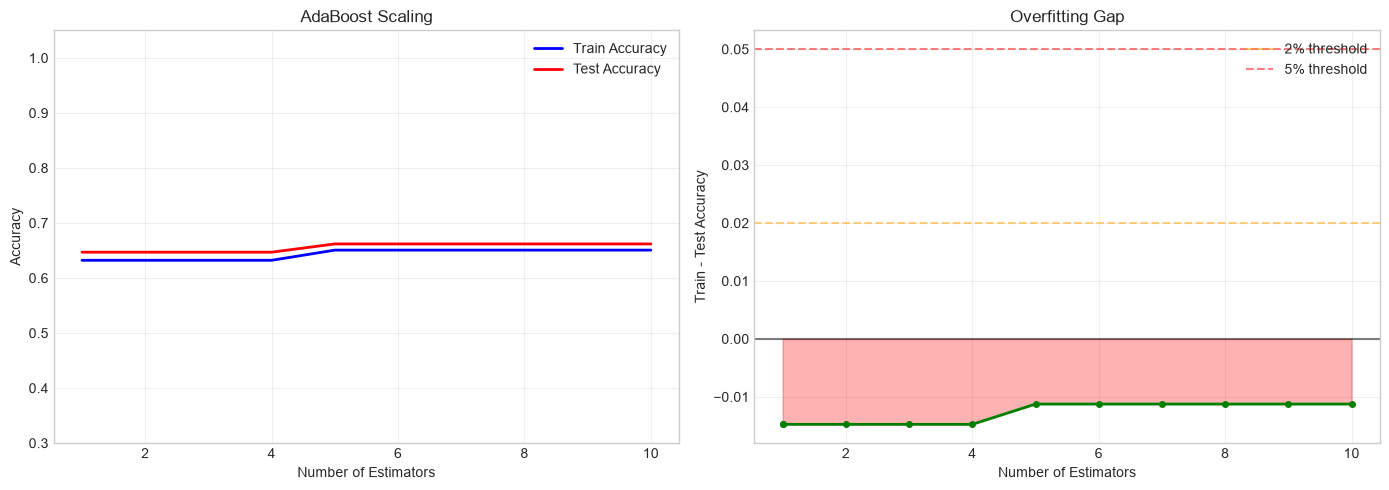


Plotting MNIST...
  Plot saved to ../figures/adaboost_scaling_MNIST.png


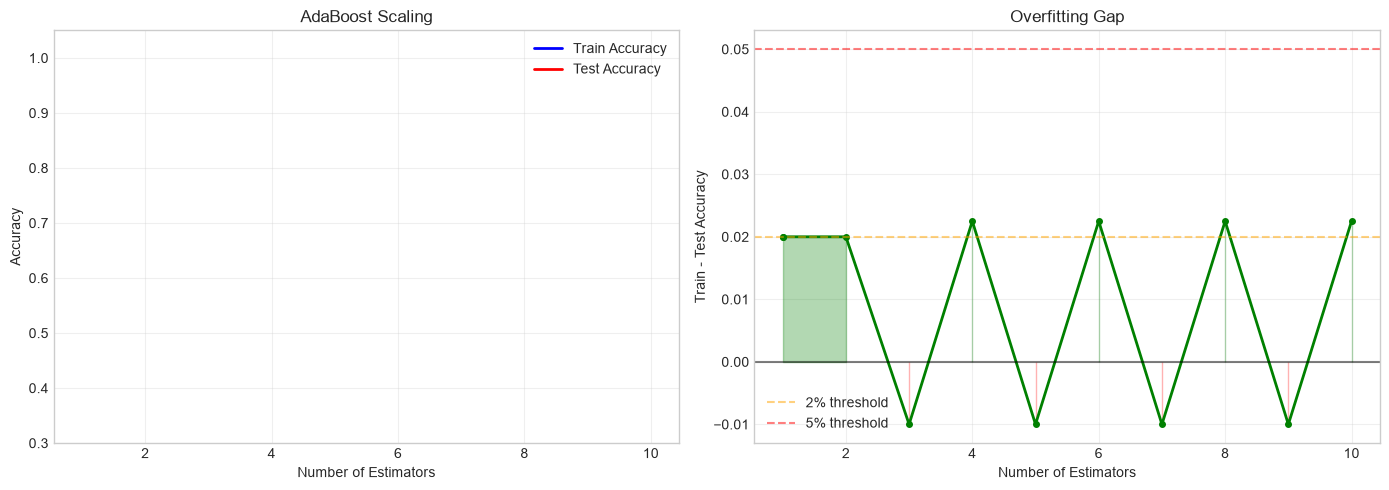

In [6]:
# Generate plots for all datasets
print("\n" + "=" * 60)
print("GENERATING PLOTS")
print("=" * 60)

for name, result in results.items():
    print(f"\nPlotting {name}...")
    plot_adaboost_scaling(result, save_path=f"../figures/adaboost_scaling_{name}.png")

# Summary table

In [7]:
# Generate summary of best results
summary = []
for name, result in results.items():
    best_idx = np.argmax(result["test_acc"])
    summary.append(
        {
            "Dataset": name,
            "Best n_estimators": result["n_estimators"][best_idx],
            "Best Test Accuracy": result["test_acc"][best_idx],
            "Best Test F1": result["test_f1"][best_idx],
            "Final Test Accuracy": result["test_acc"][-1],
            "Train-Test Gap": result["train_acc"][-1] - result["test_acc"][-1],
        }
    )

summary_df = pd.DataFrame(summary)

print("\n" + "=" * 60)
print("ADA BOOST SCALING RESULTS SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

best_overall_idx = np.argmax(summary_df["Best Test Accuracy"])
print(f"\nBest overall performance: {summary_df.iloc[best_overall_idx]['Dataset']}")
print(f"   Accuracy: {summary_df.iloc[best_overall_idx]['Best Test Accuracy']:.4f}")
print(f"   n_estimators: {summary_df.iloc[best_overall_idx]['Best n_estimators']}")


ADA BOOST SCALING RESULTS SUMMARY
      Dataset  Best n_estimators  Best Test Accuracy  Best Test F1  Final Test Accuracy  Train-Test Gap
Breast_Cancer                  5            0.947368      0.947610             0.938596        0.013052
 Adult_Income                  1            0.804791      0.751544             0.785853       -0.000068
    Covertype                  5            0.662000      0.635748             0.662000       -0.011250
        MNIST                  3            0.220000      0.084854             0.190000        0.022500

Best overall performance: Breast_Cancer
   Accuracy: 0.9474
   n_estimators: 5


# Overfitting analysis


OVERFITTING ANALYSIS

Breast_Cancer:
  Best test accuracy: 0.9474 at n=5
  Final test accuracy: 0.9386
  Max overfitting gap: 0.0131
  Final overfitting gap: 0.0131
  No significant overfitting (<2%)

Adult_Income:
  Best test accuracy: 0.8048 at n=1
  Final test accuracy: 0.7859
  Max overfitting gap: -0.0001
  Final overfitting gap: -0.0001
  No significant overfitting (<2%)

Covertype:
  Best test accuracy: 0.6620 at n=5
  Final test accuracy: 0.6620
  Max overfitting gap: -0.0112
  Final overfitting gap: -0.0112
  No significant overfitting (<2%)

MNIST:
  Best test accuracy: 0.2200 at n=3
  Final test accuracy: 0.1900
  Max overfitting gap: 0.0225
  Final overfitting gap: 0.0225
  Some overfitting detected (2-5%)


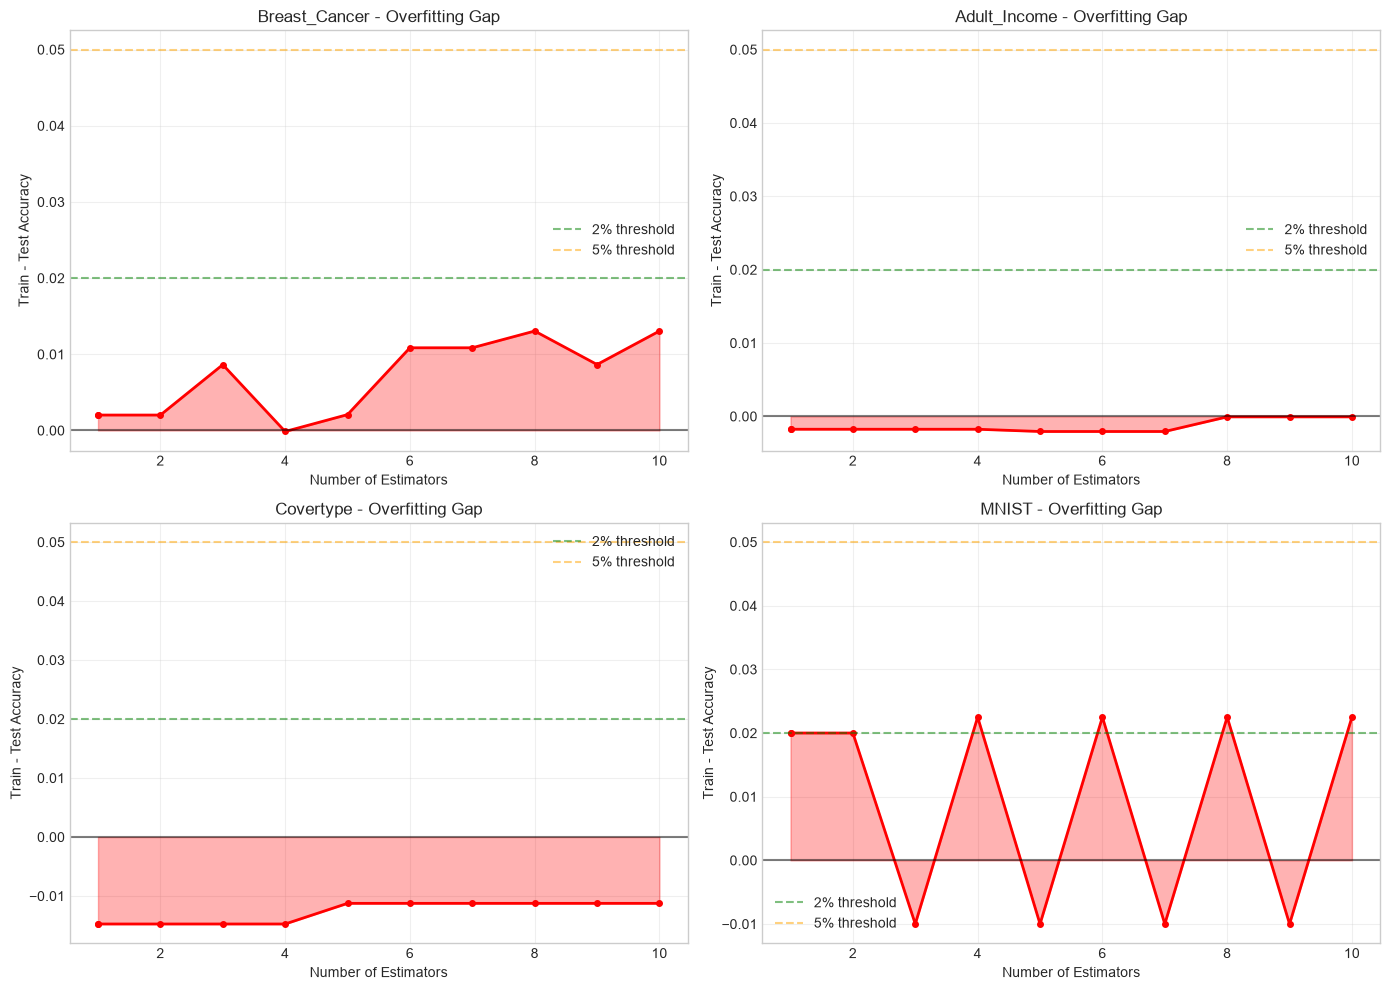


Overfitting analysis figure saved: figures/overfitting_analysis.png


In [8]:
print("\n" + "=" * 60)
print("OVERFITTING ANALYSIS")
print("=" * 60)

for name, result in results.items():
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])
    gap = train_acc - test_acc

    print(f"\n{name}:")
    print(
        f"  Best test accuracy: {max(test_acc):.4f} at n={result['n_estimators'][np.argmax(test_acc)]}"
    )
    print(f"  Final test accuracy: {test_acc[-1]:.4f}")
    print(f"  Max overfitting gap: {max(gap):.4f}")
    print(f"  Final overfitting gap: {gap[-1]:.4f}")

    if max(gap) > 0.05:
        print("  WARNING: Significant overfitting detected (>5%)")
    elif max(gap) > 0.02:
        print("  Some overfitting detected (2-5%)")
    else:
        print("  No significant overfitting (<2%)")


# Visualize overfitting gaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])
    gap = train_acc - test_acc

    ax = axes[idx]
    ax.plot(
        result["n_estimators"], gap, color="red", linewidth=2, marker="o", markersize=4
    )
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.5)
    ax.axhline(y=0.02, color="green", linestyle="--", alpha=0.5, label="2% threshold")
    ax.axhline(y=0.05, color="orange", linestyle="--", alpha=0.5, label="5% threshold")
    ax.fill_between(result["n_estimators"], 0, gap, alpha=0.3, color="red")
    ax.set_xlabel("Number of Estimators")
    ax.set_ylabel("Train - Test Accuracy")
    ax.set_title(f"{name} - Overfitting Gap")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/overfitting_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nOverfitting analysis figure saved: figures/overfitting_analysis.png")

# sklearn comparison

In [9]:
# ============================================
# SKLEARN COMPARISON (Separate Cell)
# ============================================
# ============================================
# SKLEARN COMPARISON
# ============================================
print("\n" + "=" * 60)
print("SKLEARN COMPARISON")
print("=" * 60)

comparison_results = []
for name, (X, y) in datasets.items():
    print(f"\n{name}:")
    model = trained_models[name]
    our_acc, sk_acc = compare_with_sklearn(model, X, y, name)
    comparison_results.append(
        {
            "Dataset": name,
            "Our Accuracy": our_acc,
            "sklearn Accuracy": sk_acc,
            "Difference": abs(our_acc - sk_acc),
            "Pass": abs(our_acc - sk_acc) < 0.02,
        }
    )

comparison_df = pd.DataFrame(comparison_results)

print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
print(comparison_df.to_string(index=False))

all_passed = all(comparison_df["Pass"])
if all_passed:
    print("\nAll datasets passed the 2% tolerance check!")
else:
    print("\nSome datasets failed the 2% tolerance check!")


SKLEARN COMPARISON

Breast_Cancer:
  Breast_Cancer: Our=0.9386, sklearn=0.9386, diff=0.0000

Adult_Income:
  Adult_Income: Our=0.7859, sklearn=0.7859, diff=0.0000

Covertype:
  Covertype: Our=0.6620, sklearn=0.6620, diff=0.0000

MNIST:
  MNIST: Our=0.1900, sklearn=0.1900, diff=0.0000

COMPARISON SUMMARY
      Dataset  Our Accuracy  sklearn Accuracy  Difference  Pass
Breast_Cancer      0.938596          0.938596         0.0  True
 Adult_Income      0.785853          0.785853         0.0  True
    Covertype      0.662000          0.662000         0.0  True
        MNIST      0.190000          0.190000         0.0  True

All datasets passed the 2% tolerance check!


# Save all results

In [10]:
os.makedirs("../notebooks", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

print("\n" + "=" * 60)
print("SAVING SUMMARY RESULTS")
print("=" * 60)

# Save summary table
summary_df.to_csv("../notebooks/adaboost_scaling_summary.csv", index=False)
print("Summary saved: notebooks/adaboost_scaling_summary.csv")

# Save best results with sample sizes
best_results = []
for name, result in results.items():
    best_idx = np.argmax(result["test_acc"])
    train_acc = np.array(result["train_acc"])
    test_acc = np.array(result["test_acc"])

    if name == "Covertype":
        sample_size = (
            COVERTYPE_SAMPLE_SIZE
            if COVERTYPE_SAMPLE_SIZE is not None
            else len(datasets[name][0])
        )
    elif name == "MNIST":
        sample_size = (
            MNIST_SAMPLE_SIZE
            if MNIST_SAMPLE_SIZE is not None
            else len(datasets[name][0])
        )
    else:
        sample_size = len(datasets[name][0])

    best_results.append(
        {
            "Dataset": name,
            "Sample Size": sample_size,
            "Best n_estimators": result["n_estimators"][best_idx],
            "Best Test Accuracy": result["test_acc"][best_idx],
            "Best Test F1": result["test_f1"][best_idx],
            "Final Test Accuracy": result["test_acc"][-1],
            "Train-Test Gap": result["train_acc"][-1] - result["test_acc"][-1],
            "Max Overfitting Gap": max(train_acc - test_acc),
            "Number of Classes": len(np.unique(datasets[name][1])),
        }
    )

best_df = pd.DataFrame(best_results)
best_df.to_csv("../notebooks/adaboost_scaling_best_results.csv", index=False)
print("Best results saved: notebooks/adaboost_scaling_best_results.csv")

# Save sklearn comparison
comparison_df.to_csv(
    "../notebooks/adaboost_scaling_sklearn_comparison.csv", index=False
)
print("sklearn comparison saved: notebooks/adaboost_scaling_sklearn_comparison.csv")

# Save experiment metadata
metadata = {
    "experiment": "AdaBoost Scaling (Staged Approach)",
    "date": time.strftime("%Y-%m-%d %H:%M:%S"),
    "max_estimators": MAX_ESTIMATORS,
    "step": STEP,
    "n_estimators_list": N_ESTIMATORS_LIST,
    "datasets": list(datasets.keys()),
    "covertype_sample_size": COVERTYPE_SAMPLE_SIZE,
    "mnist_sample_size": MNIST_SAMPLE_SIZE,
    "total_time_seconds": TOTAL_TIME,
    "results_summary": summary_df.to_dict(orient="records"),
}

with open("../notebooks/experiment_metadata.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["key", "value"])
    for key, value in metadata.items():
        if key != "results_summary" and key != "n_estimators_list":
            writer.writerow([key, value])
        elif key == "n_estimators_list":
            writer.writerow([key, str(value)])

print("Metadata saved: notebooks/experiment_metadata.csv")

print("\n" + "=" * 60)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("=" * 60)
print("  Individual dataset results: notebooks/adaboost_scaling_*_details.csv")
print("  Individual metadata: notebooks/adaboost_scaling_*_metadata.csv")
print("  Staged predictions: notebooks/staged_predictions_*.csv")
print("  Summary: notebooks/adaboost_scaling_summary.csv")
print("  Best results: notebooks/adaboost_scaling_best_results.csv")
print("  sklearn comparison: notebooks/adaboost_scaling_sklearn_comparison.csv")
print("=" * 60)


SAVING SUMMARY RESULTS
Summary saved: notebooks/adaboost_scaling_summary.csv
Best results saved: notebooks/adaboost_scaling_best_results.csv
sklearn comparison saved: notebooks/adaboost_scaling_sklearn_comparison.csv
Metadata saved: notebooks/experiment_metadata.csv

ALL RESULTS SAVED SUCCESSFULLY
  Individual dataset results: notebooks/adaboost_scaling_*_details.csv
  Individual metadata: notebooks/adaboost_scaling_*_metadata.csv
  Staged predictions: notebooks/staged_predictions_*.csv
  Summary: notebooks/adaboost_scaling_summary.csv
  Best results: notebooks/adaboost_scaling_best_results.csv
  sklearn comparison: notebooks/adaboost_scaling_sklearn_comparison.csv


# Final summary output

In [11]:
print("\nDATASETS SUMMARY")
print("-" * 40)
for name, (X, y) in datasets.items():
    if name == "Covertype":
        sample_size = (
            COVERTYPE_SAMPLE_SIZE if COVERTYPE_SAMPLE_SIZE is not None else X.shape[0]
        )
        full_size = X.shape[0]
    elif name == "MNIST":
        sample_size = MNIST_SAMPLE_SIZE if MNIST_SAMPLE_SIZE is not None else X.shape[0]
        full_size = X.shape[0]
    else:
        sample_size = X.shape[0]
        full_size = X.shape[0]

    print(f"  {name}:")
    if name in ["Covertype", "MNIST"] and sample_size != full_size:
        print(f"    Samples: {sample_size:,} (subsampled from {full_size:,})")
    else:
        print(f"    Samples: {sample_size:,}")
    print(f"    Features: {X.shape[1]}")
    print(f"    Classes: {len(np.unique(y))}")
    if len(np.unique(y)) <= 10:
        print(f"    Class distribution: {np.bincount(y.astype(int))}")

print("\nBEST RESULTS PER DATASET")
print("-" * 40)
if "best_df" in locals():
    print(best_df.to_string(index=False))
else:
    print("Error: best_df not defined.")

print("\nKEY FINDINGS")
print("-" * 40)

if "best_df" in locals():
    best_row = best_df.loc[best_df["Best Test Accuracy"].idxmax()]
    print(f"  Best Overall Accuracy: {best_row['Dataset']}")
    print(f"     Accuracy: {best_row['Best Test Accuracy']:.4f}")
    print(f"     n_estimators: {best_row['Best n_estimators']}")

    best_f1_row = best_df.loc[best_df["Best Test F1"].idxmax()]
    print(f"\n  Best Overall F1: {best_f1_row['Dataset']}")
    print(f"     F1: {best_f1_row['Best Test F1']:.4f}")
    print(f"     n_estimators: {best_f1_row['Best n_estimators']}")

    print("\n  Overfitting Analysis:")
    for _, row in best_df.iterrows():
        gap = row["Max Overfitting Gap"]
        status = "Low" if gap < 0.02 else "Moderate" if gap < 0.05 else "High"
        print(f"    {row['Dataset']}: Max gap = {gap:.4f} ({status})")
else:
    print("  Run the experiment first to generate best_results.")

print("\n  sklearn Validation:")
for _, row in comparison_df.iterrows():
    status = "Pass" if row["Pass"] else "Fail"
    print(f"    {row['Dataset']}: Diff = {row['Difference']:.4f} ({status})")

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)


DATASETS SUMMARY
----------------------------------------
  Breast_Cancer:
    Samples: 569
    Features: 30
    Classes: 2
    Class distribution: [212 357]
  Adult_Income:
    Samples: 48,842
    Features: 6
    Classes: 2
    Class distribution: [37155 11687]
  Covertype:
    Samples: 5,000
    Features: 10
    Classes: 7
    Class distribution: [   0 1841 2397  324   25   88  150  175]
  MNIST:
    Samples: 500
    Features: 784
    Classes: 10
    Class distribution: [53 56 46 60 43 45 49 49 49 50]

BEST RESULTS PER DATASET
----------------------------------------
      Dataset  Sample Size  Best n_estimators  Best Test Accuracy  Best Test F1  Final Test Accuracy  Train-Test Gap  Max Overfitting Gap  Number of Classes
Breast_Cancer          569                  5            0.947368      0.947610             0.938596        0.013052             0.013052                  2
 Adult_Income        48842                  1            0.804791      0.751544             0.785853       -0

In [12]:
t2 = time.perf_counter()